In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plotsettings import *
import limpy.theory as lt

/Users/anirbanroy/opt/anaconda3/lib/python3.8/site-packages/limpy-1.0-py3.8.egg/limpy/theory.py:234: RuntimeWarning: divide by zero encountered in true_divide
  Lcii=F_z*((Mhalo/M1)**beta)*np.exp(-N1/Mhalo)
<ipython-input-3-b0398444d0be>:10: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')


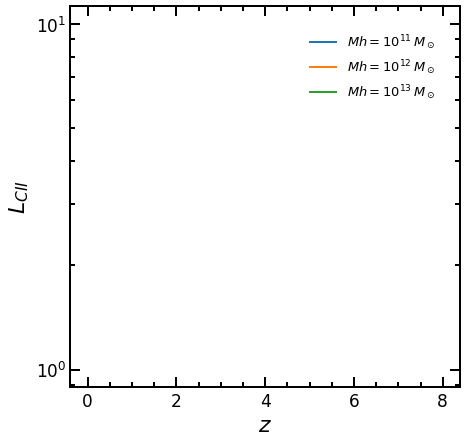

In [3]:
# Plot L_CII for different halo mass and redshift using LCII-Mhalo fitting formula
z=np.linspace(0, 8, num=50)
l_m11=lt.mhalo_to_lcp_fit(z,10**11)
l_m12=lt.mhalo_to_lcp_fit(z,10**12)
l_m13=lt.mhalo_to_lcp_fit(z,10**13)
lw=2.0
plt.plot(z, l_m11, lw=lw, label=r'$Mh=10^{11}\,M_\odot$')
plt.plot(z, l_m12, lw=lw, label=r'$Mh=10^{12}\,M_\odot$')
plt.plot(z, l_m13, lw=lw, label=r'$Mh=10^{13}\,M_\odot$')
plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$L_{CII}$')
plt.legend(loc=0, frameon=False)

Text(0, 0.5, '$I_z\\,\\,(Jy/sr)$')

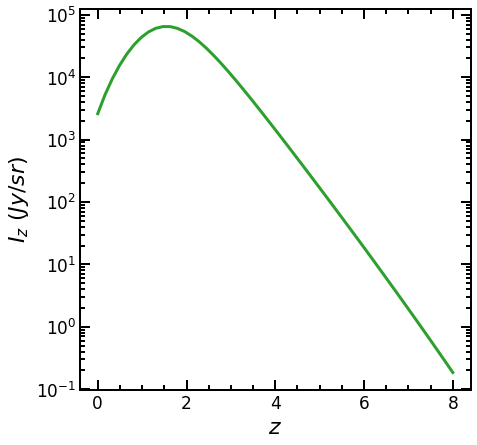

In [4]:
# Plot average intensity 
nu_rest_CII=1900 #Ghz
Iav=[lt.I_nu(zz,nu_rest_CII,z_line=0.0) for zz in z]
plt.plot(z, Iav, lw=3.0, color='C2')

plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel(r'$I_z\,\,(Jy/sr)$')

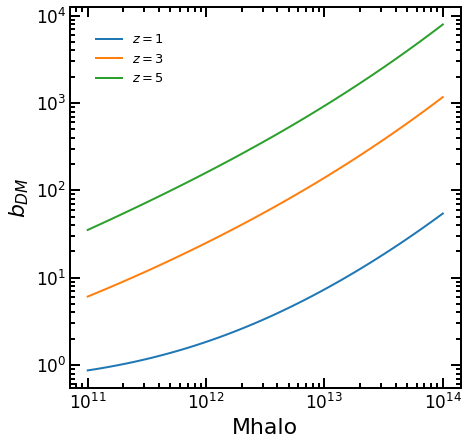

In [5]:
# plot Dark matter bias
m=np.logspace(11, 14)
pz1=lt.bias_dm(m,1.0)
pz3=lt.bias_dm(m,3.0)
pz5=lt.bias_dm(m,5.0)

plt.plot(m,pz1,lw=lw,label=r'$z=1$')
plt.plot(m,pz3,lw=lw,label=r'$z=3$')
plt.plot(m,pz5,lw=lw,label=r'$z=5$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mhalo')
plt.ylabel(r'$b_{DM}$')
plt.legend(loc=0, frameon=False)

Text(0, 0.5, '$b_{CII}$')

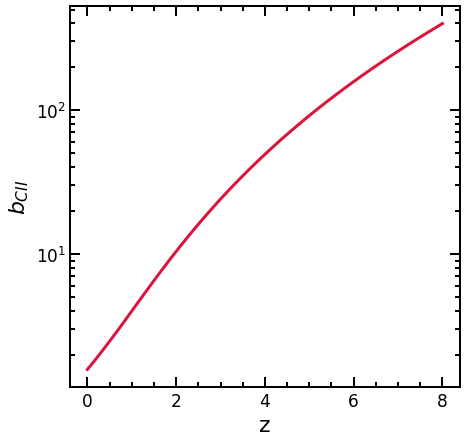

In [6]:
# plot bias of CII lines

bline=[lt.b_line(zz) for zz in z]
plt.plot(z,bline,lw=3, color='crimson')
plt.yscale('log')
plt.xlabel('z')
plt.ylabel(r'$b_{CII}$')

In [7]:
# plot all the power spectra
zline=5.0
nu_rest_line=1900 #GhZ
k=np.logspace(-3, 2, num=20)
pkshot=[lt.Pk_line(kk,zline,nu_rest_line,label='shot') for kk in k]
pkclus=[lt.Pk_line(kk,zline,nu_rest_line,label='clustering') for kk in k]
pktotal=[lt.Pk_line(kk,zline,nu_rest_line,label='total') for kk in k]

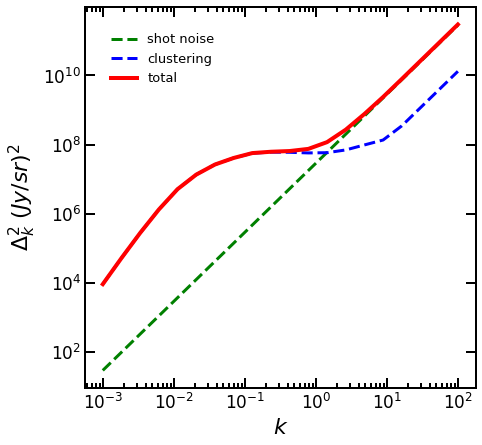

In [8]:
plt.plot(k, k**2*pkshot/2.0/np.pi, lw=3, ls='--', color='g', label="shot noise")
plt.plot(k, k**2*pkclus/2.0/np.pi, lw=3, ls='--', color='b',label="clustering")
plt.plot(k, k**2*pktotal/2.0/np.pi, lw=4, color='r',label="total")

plt.ylabel(r'$\Delta^2_k\,\,(Jy/sr)^2$')
plt.xlabel(r'$k$')
plt.yscale('log')
plt.xscale('log')
plt.legend(loc=0, frameon=False)